In [16]:
import sys
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import h5py
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
# gapmoe_model = gapmoe(rhos_path="../test_data/hist_D.dat",mass_path="../test_data/hist_M.dat",mu_path="../test_data/hist_murel.dat")
# gapmoe_model.set_data()
JD0 = 0
from scipy.optimize import minimize

In [65]:
tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

In [66]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [67]:
def mag2flux(mag):
    return 10**(-mag / 2.5)

def flux2mag(flux):
    return -2.5 * np.log10(flux)

def magerr2fluxerr(mag, mag_err):
    flux = mag2flux(mag)
    flux_err = flux * (np.log(10) / 2.5) * mag_err
    return flux_err

In [68]:
def linear_fit(x,y,w):
    w_sum = np.sum(w)
    wxy_sum = np.sum(w*x*y)
    wx_sum = np.sum(w*x)
    wy_sum = np.sum(w*y)
    wxx_sum = np.sum(w*x*x)
    bunbo = w_sum*wxx_sum-wx_sum**2
    a = (w_sum*wxy_sum-wx_sum*wy_sum)/bunbo
    b = (wxx_sum*wy_sum-wx_sum*wxy_sum)/bunbo
    y_fit = a * x + b
    chi2 = np.sum(w * (y - y_fit) ** 2)
    return a,b,chi2

In [69]:
cVIBoya = 0.50141358
dVIBoya = 0.41968496
EVI, AI = 1.483,  1.822
def calc_thS(_fs_I,_fs_v):
    I_S = flux2mag(_fs_I)
    V_S = flux2mag(_fs_v)
    VI_S = V_S - I_S
    
    I0_S = I_S - AI
    VI0_S = VI_S - EVI
    
    _theta_star  = 0.5*10**(cVIBoya + dVIBoya*VI0_S  - 0.2*I0_S)
    return _theta_star

In [70]:
path_moa = "/moao38_7/nunota/HSC_FFP/colab_data/moa_magerror_clear.dat"
data_moa = np.genfromtxt(path_moa,names=["mag","med","ul","ll"],usecols=[0,1,2,3])

mag_vals_moa = data_moa['mag']
med_vals_moa = data_moa['med']
ul_vals_moa = data_moa['ul']
ll_vals_moa = data_moa['ll']

def get_mag_err_moa(mag):
    med_interp = np.interp(mag, mag_vals_moa, med_vals_moa)
    ul_interp = np.interp(mag, mag_vals_moa, ul_vals_moa)
    ll_interp = np.interp(mag, mag_vals_moa, ll_vals_moa)

    sigma = (ul_interp - ll_interp) / 4 
    random_value = np.random.normal(med_interp, sigma)

    return np.clip(random_value, ll_interp, ul_interp)

In [71]:
list_path = "../../binfit/work/MB23162/data/v2/list_vbml"

#----------read list------------#
data_path_list, data_names = {},[]
with open(list_path,"r") as f:
    for line in f:
        line = line.strip().split()
        _tmp_name = line[1]+"_"+line[2]
        data_names.append(_tmp_name)
        data_path_list[_tmp_name] = line[0]

data_set = {}
for _name in data_names:
    _tmp_data = np.genfromtxt("../../binfit/work/MB23162/"+data_path_list[_name],usecols=(0,1,2),names=["time","flux","ferr"])
    _tmp_data = _tmp_data[np.where(_tmp_data["ferr"]>0)]
    _tmp_data = _tmp_data[np.where(_tmp_data["time"]>10000)]
    data_set[_name] = _tmp_data

In [72]:
data_set.keys()

dict_keys(['MOA_Red', 'MOA_V', 'KMT-A02_I', 'KMT-A03_I', 'KMT-A42_I', 'KMT-A43_I', 'KMT-C02_I', 'KMT-C02_V', 'KMT-C03_I', 'KMT-C03_V', 'KMT-C42_I', 'KMT-C42_V', 'KMT-C43_I', 'KMT-C43_V', 'KMT-S02_I', 'KMT-S03_I', 'KMT-S42_I', 'KMT-S43_I'])

In [115]:
Is = 18 + AI
Vs = 1 + 18 + EVI
fs_I = mag2flux(Is)
fs_V = mag2flux(Vs)
thS =jnp.float32(calc_thS(fs_I, fs_V))
print(thS)
print("\n")
     
t0 = 10090 - 5       
u0 = 0.01          
q = 0.005
alpha = 3.68*np.pi/4
tE = 60
s = 0.95
rho = 2e-04
piEN =  1.0e-01
piEE = 1.0e-01
Ds = 8.1

x0 =  jnp.array([t0, tE, u0, rho , piEN, piEE,Ds])
parametrics.lightcurve_to_physical_single(x0,thS,vEarth)

0.0001800539




Array([1.0085000e+04, 9.9999998e-03, 7.8176892e-01, 3.9876523e+00,
       8.1000004e+00, 3.9357593e+00, 3.7896099e+00], dtype=float32)

In [117]:
pr = [math.log(s), math.log(q), u0, alpha, math.log(rho), math.log(tE), t0+JD0, piEN, piEE]

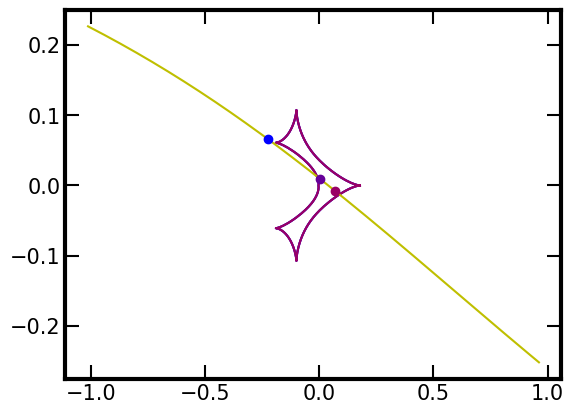

In [118]:
t = np.linspace(t0-tE+JD0, t0+JD0+tE, 300)
_, y1, y2 = VBM.BinaryLightCurveParallax(pr,t)   

caustictimes = [115,150,160]
colors = [(0,0,1,1),(0.4,0,0.6,1),(0.6,0,0.4,1)]
for i in range(0,3):
    caustics = VBM.Caustics(s,q)
    for cau in caustics:
        plt.plot(cau[0],cau[1],color = colors[i])
plt.plot(y1,y2,"y")
for i in range(0,3):
    plt.plot([y1[caustictimes[i]]],[y2[caustictimes[i]]],color=colors[i],marker="o")
    
# t = np.linspace(t0+100-tE+JD0, t0+100+JD0+tE, 300)
# _, y1, y2,sorb = VBM.BinaryLightCurveKepler(pr,t)   

# caustictimes = [115,150,160]
# colors = [(0,0,1,1),(0.4,0,0.6,1),(0.6,0,0.4,1)]
# for i in range(0,3):
#     caustics = VBM.Caustics(sorb[caustictimes[i]],q)
#     for cau in caustics:
#         plt.plot(cau[0],cau[1],color = colors[i])
# plt.plot(y1,y2,"y")
# for i in range(0,3):
#     plt.plot([y1[caustictimes[i]]],[y2[caustictimes[i]]],color=colors[i],marker="o")

In [119]:
np.random.seed(46)

simu_data = {}
for name in data_set.keys():
#     if "KMT" in name:
#         continue
    if "42" in name or "43" in name: 
        continue
    time = data_set[name]["time"]
    amp = np.array(VBM.BinaryLightCurveParallax(pr, time + JD0)[0])
    
    if "I" in name or "Red" in name:
        model_flux = amp * fs_I + mag2flux(20)
    else:
        model_flux = amp * fs_V + mag2flux(22)

    lc_model = np.empty(len(time), dtype=[
        ("time", float), 
        ("flux", float),      
        ("mag", float),     
        ("merr", float),    
        ("ferr", float),    
        ("mag_obs", float), 
        ("flux_obs", float),
    ])
    
    lc_model["time"] = time
    lc_model["flux"] = model_flux
    lc_model["mag"] = flux2mag(model_flux)

    if "I" in name or "Red" in name:
        lc_model["merr"] = get_mag_err_moa(lc_model["mag"]) * 100
    else:
        lc_model["merr"] = get_mag_err_moa(lc_model["mag"]) * 200

    lc_model["ferr"] = np.abs(
        magerr2fluxerr(lc_model["mag"], lc_model["merr"])
    )

    lc_model["flux_obs"] = lc_model["flux"] + np.random.normal(0, lc_model["ferr"])
    lc_model["mag_obs"] = flux2mag(lc_model["flux_obs"])

    simu_data[name] = lc_model

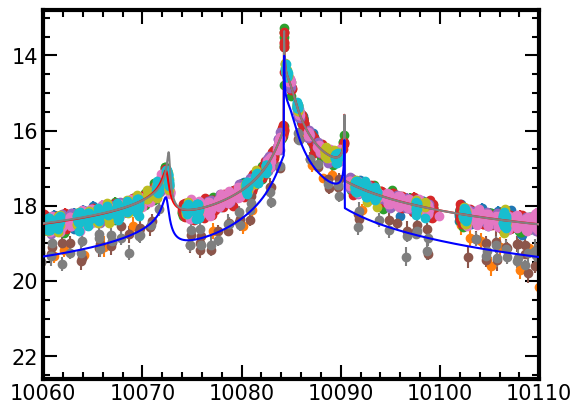

In [120]:
t_plot = np.linspace(JD0+10060,JD0+10110,10000)
amp_plot = np.array(VBM.BinaryLightCurveParallax(pr, t_plot)[0])
amp_plot_sta = np.array(VBM.BinaryLightCurve(pr, t_plot)[0])
mag_plot_I = flux2mag(amp_plot * fs_I + mag2flux(20))
mag_plot_V = flux2mag(amp_plot * fs_V + mag2flux(22))
mag_plot_I_sta = flux2mag(amp_plot_sta * fs_I + mag2flux(20))
plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_I_sta,c="gray",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")
    
plt.xlim(JD0+10060,JD0+10110)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.show()

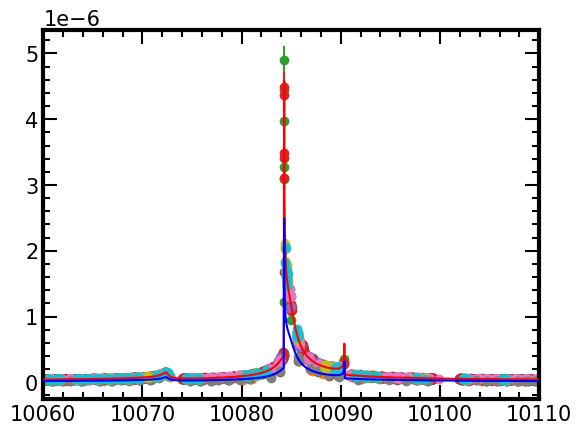

In [121]:
t_plot = np.linspace(JD0+10060,JD0+10110,10000)
amp_plot = np.array(VBM.BinaryLightCurveParallax(pr, t_plot)[0])
mag_plot_I = amp_plot * fs_I + mag2flux(20)
mag_plot_V = amp_plot * fs_V + mag2flux(22)
plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["flux_obs"], simu_data[name]["ferr"],fmt="o") 

plt.xlim(JD0+10060,JD0+10110)
plt.minorticks_on()

plt.show()

In [122]:
# np.savez("../simu_data/simu_data_06_kepler.npz", **simu_data)